# A function, then a file

A chart you will draw more than once belongs in a function. The function receives the panel, draws one question, and leaves the page size to the caller.

The file is a second step. `fig.savefig` writes the page you name. `plt.savefig` writes whatever page is current. With two pages open, those are not the same object.

A PNG file starts with the eight bytes

$$
137,\ 80,\ 78,\ 71,\ 13,\ 10,\ 26,\ 10
$$

which as text look like a broken "PNG" header. Checking those bytes tells you that you wrote an image and not an empty file or a traceback saved by mistake.


png bytes 24569
figure size in inches (np.float64(7.2), np.float64(4.2))


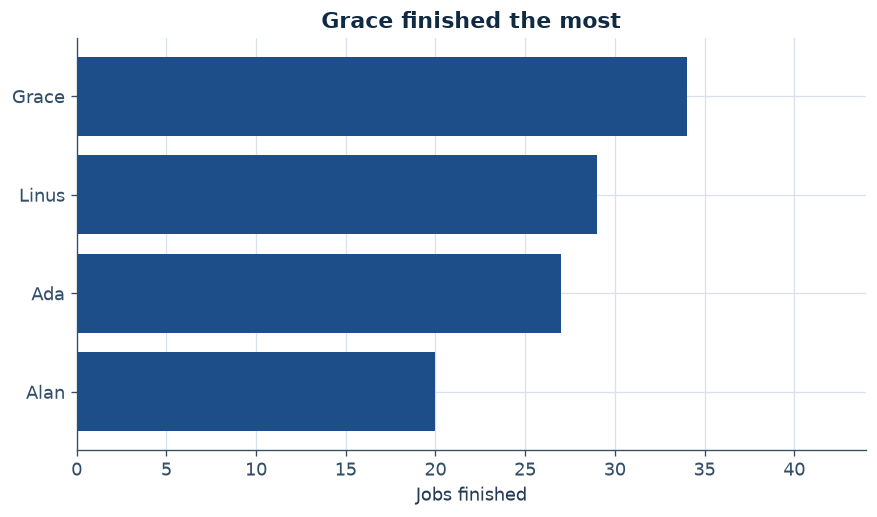

In [1]:
# The drawing function returns the same panel it was given.
import io
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "font.size": 11,
})
BLUE = "#1d4e89"

def draw_ranking(ax, names, totals):
    # Sorted copy: smallest at the bottom, largest at the top.
    order = sorted(range(len(totals)), key=lambda i: totals[i])
    ax.barh([names[i] for i in order], [totals[i] for i in order], color=BLUE)
    ax.set_xlabel("Jobs finished")
    ax.set_xlim(0, 44)
    ax.set_title("Grace finished the most")
    return ax

fig, ax = plt.subplots(constrained_layout=True, figsize=(7.2, 4.2), dpi=120)
draw_ranking(ax, ["Ada", "Grace", "Alan", "Linus"], [27, 34, 20, 29])
assert ax.patches[-1].get_width() == 34

buffer = io.BytesIO()
fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight", facecolor="white")
payload = buffer.getvalue()
assert payload[:8] == b"\x89PNG\r\n\x1a\n"
assert len(payload) > 1000
print("png bytes", len(payload))
print("figure size in inches", tuple(fig.get_size_inches()))


## Save the page you mean

Two pages are open. The first is the ranking. The second is a single-point decoy. Calling `savefig` on the first page must not switch to the decoy. The width of the top bar on that first page is still Grace's $34$.


saved the ranking page, not the decoy that was current


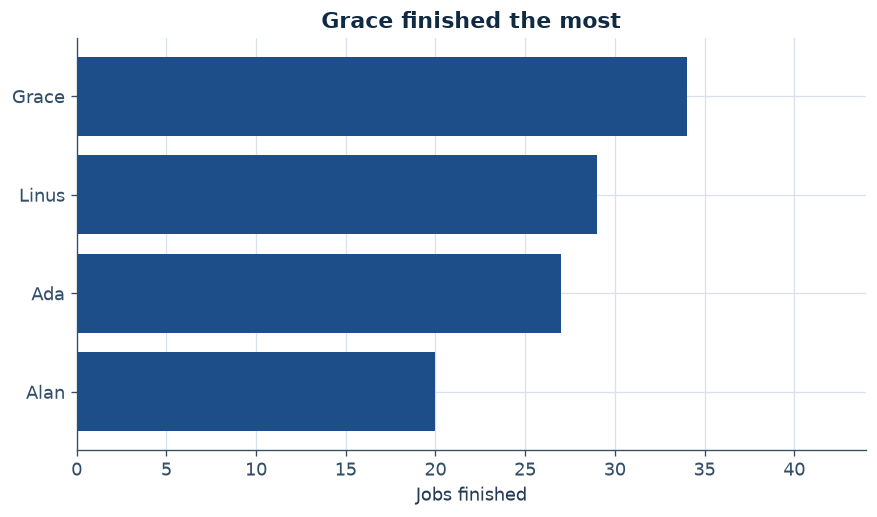

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Hold the figure in a variable. Save that variable, not "the current figure".
import io

def draw_ranking(ax, names, totals):
    order = sorted(range(len(totals)), key=lambda i: totals[i])
    ordered_names = [names[i] for i in order]
    ordered_totals = [totals[i] for i in order]
    ax.barh(ordered_names, ordered_totals, color=BLUE)
    ax.set_xlabel("Jobs finished")
    ax.set_xlim(0, 44)
    ax.set_title("Grace finished the most")
    return ordered_totals

ranking, ranking_ax = plt.subplots(constrained_layout=True)
ordered = draw_ranking(ranking_ax, ["Ada", "Grace", "Alan", "Linus"], [27, 34, 20, 29])
decoy, decoy_ax = plt.subplots()
decoy_ax.plot([0, 1], [0, 1], color=CLAY)
decoy_ax.set_title("Not the file we want")
assert ordered[-1] == 34
assert plt.gcf() is decoy
buffer = io.BytesIO()
ranking.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor="white")
assert buffer.getvalue()[:8] == b"\x89PNG\r\n\x1a\n"
plt.close(decoy)
print("saved the ranking page, not the decoy that was current")


## A pitfall

Saving before the labels fit on the page clips the title or the last tick. `bbox_inches="tight"` includes the labels in the file. Saving the interactive window by screenshot does not record the dpi you asked for, and it often includes the editor around the chart. Write the file from `fig.savefig` and check the PNG header.

A useful name says the subject and the date, not the chart type: `north-lab-week-ranking.png`.

## What to carry forward

Draw inside a function that takes an axes. Save the figure object you built. The ranking file is a PNG, and its top bar is $34$.
